In [13]:
# Uncomment if needed
!pip install -q category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 5.4 MB/s eta 0:00:00


In [14]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder

from google.colab import drive

In [15]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
PROJECT_DIR="/content/drive/MyDrive/Ghana_Dropout_Project"

In [17]:
df = pd.read_csv(
    f"{PROJECT_DIR}/cleaned_data.csv"
)

print(df.shape)

df.head()

(1000, 41)


,school_code,geographic_zone,school_type,data_source,gender,age_at_start_of_academic_year,class_level,grade_repetition_count,term_1_attendance,term_2_attendance,...,school_enjoyment,missed_school_for_choreswork,missed_school_due_to_illness,barriers_to_regular_attendance,family_income_level,parent_attends_school_events,behaviour_warnings_punishments,class_participation,extracurricular_activities,dropout_label
0,KNU_JHS,Peri-urban,Public,Questionnaire,Male,10.0,JHS1,0,85.0,82.0,...,3.0,No,"Yes, more than once",Nothing-come regularly,Medium,Sometimes,Never,5.0,1 activity,0
1,KNU_JHS,Peri-urban,Public,Questionnaire,Male,11.0,JHS1,0,87.0,79.0,...,3.0,No,"Yes, more than once",Nothing-come regularly,Medium,Rarely,Once,2.0,2 activities,0
2,KNU_JHS,Peri-urban,Public,Questionnaire,Male,10.0,JHS1,0,70.0,79.0,...,1.0,Yes,"Yes, more than once",Health problems,Medium,Sometimes,Never,5.0,2 activities,0
3,KNU_JHS,Peri-urban,Public,Questionnaire,Female,12.0,JHS1,0,80.0,83.0,...,4.0,No,"Yes, once",Nothing-come regularly,High,Often,Never,4.0,2 activities,0
4,KNU_JHS,Peri-urban,Public,Questionnaire,Female,10.0,JHS1,0,77.0,80.0,...,3.0,No,"Yes, more than once",Nothing-come regularly,High,Sometimes,Never,4.0,1 activity,0


In [18]:
TARGET = "dropout_label"

print(df[TARGET].value_counts())

dropout_label
0    908
1     92
Name: count, dtype: int64


In [19]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

In [20]:
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric:", len(numeric_cols))
print("Categorical:", len(categorical_cols))

Numeric: 16
Categorical: 24


In [21]:
for col in numeric_cols:

    df[col] = df[col].fillna(df[col].median())

In [22]:
for col in categorical_cols:

    df[col] = df[col].fillna(df[col].mode()[0])

In [23]:
label_encoders = {}

for col in categorical_cols:

    encoder = LabelEncoder()

    df[col] = encoder.fit_transform(df[col].astype(str))

    label_encoders[col] = encoder

In [24]:
print(df.isnull().sum().sum())

0


In [25]:
constant_cols = []

for col in df.columns:

    if df[col].nunique() <= 1:

        constant_cols.append(col)

df.drop(columns=constant_cols,
        inplace=True)

print("Removed:", constant_cols)

Removed: []


In [26]:
low_variance = []

for col in df.columns:

    if col == TARGET:

        continue

    if df[col].value_counts(normalize=True).iloc[0] > 0.99:

        low_variance.append(col)

df.drop(columns=low_variance,
        inplace=True)

print(low_variance)

[]


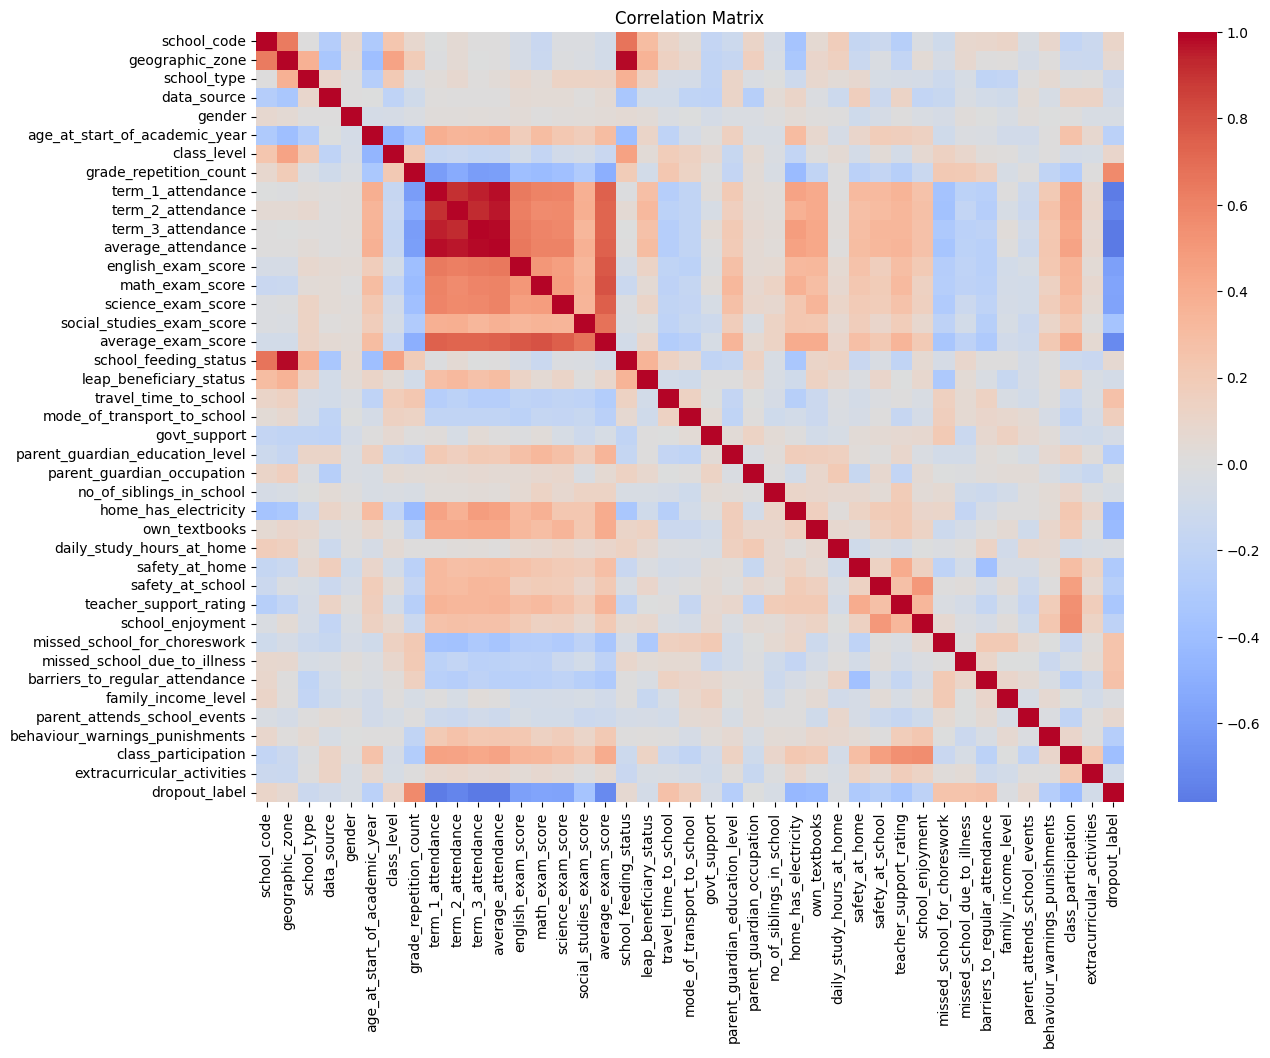

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [28]:
corr_matrix = df.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape),k=1).astype(bool)
)

to_drop = [

    column

    for column in upper.columns

    if any(upper[column] > 0.95)

]

df.drop(columns=to_drop,
        inplace=True)

print(to_drop)

['average_attendance', 'school_feeding_status']


In [29]:
for col in df.columns:

    if col == TARGET:

        continue

    if df[col].equals(df[TARGET]):

        print(f"Leakage detected: {col}")

In [30]:
corr = df.corr(numeric_only=True)[TARGET]

corr = corr.sort_values(
    ascending=False
)

print(corr)

dropout_label                      1.000000
grade_repetition_count             0.570732
travel_time_to_school              0.272197
barriers_to_regular_attendance     0.270729
missed_school_due_to_illness       0.250833
missed_school_for_choreswork       0.248895
mode_of_transport_to_school        0.170818
school_code                        0.102843
class_level                        0.097541
parent_attends_school_events       0.075979
geographic_zone                    0.061192
parent_guardian_occupation        -0.006874
family_income_level               -0.017573
daily_study_hours_at_home         -0.027989
gender                            -0.043008
no_of_siblings_in_school          -0.047485
govt_support                      -0.052128
leap_beneficiary_status           -0.072775
extracurricular_activities        -0.083561
data_source                       -0.091290
school_type                       -0.126125
school_enjoyment                  -0.212370
age_at_start_of_academic_year   

In [31]:
print(df.shape)

df.head()

(1000, 39)


,school_code,geographic_zone,school_type,data_source,gender,age_at_start_of_academic_year,class_level,grade_repetition_count,term_1_attendance,term_2_attendance,...,school_enjoyment,missed_school_for_choreswork,missed_school_due_to_illness,barriers_to_regular_attendance,family_income_level,parent_attends_school_events,behaviour_warnings_punishments,class_participation,extracurricular_activities,dropout_label
0,1,0,1,1,1,10.0,0,0,85.0,82.0,...,3.0,0,3,3,4,5,2,5.0,0,0
1,1,0,1,1,1,11.0,0,0,87.0,79.0,...,3.0,0,3,3,4,4,3,2.0,1,0
2,1,0,1,1,1,10.0,0,0,70.0,79.0,...,1.0,2,3,0,4,5,2,5.0,1,0
3,1,0,1,1,0,12.0,0,0,80.0,83.0,...,4.0,0,4,3,2,3,2,4.0,1,0
4,1,0,1,1,0,10.0,0,0,77.0,80.0,...,3.0,0,3,3,2,5,2,4.0,0,0


In [32]:
df.to_csv(
    f"{PROJECT_DIR}/engineered_data.csv",
    index=False
)

print("Engineered dataset saved successfully.")

Engineered dataset saved successfully.
